# Алгоритмы кластеризации

Задание на сегодня состоит из двух задач. Нужно реализовать алгоритмы k-means и иерархическую кластеризацию.

### 1. K-Means (1 балл)

Реализуйте метод сжатия изображений в формате PNG с помощью кластеризации пикселей. 

Общая схема работы метода:

* С помощью алгоритма Ллойда построить по изображению набор из **K** базовых цветов. Базовый цвет – это центроид в пространстве RGB.

* Преобразовать исходное изображение в новое, в котором каждый пиксель заменен на ближайший к нему базовый цвет.

Необходимо, чтобы преобразованное изображение визуально не сильно отличалось от исходного

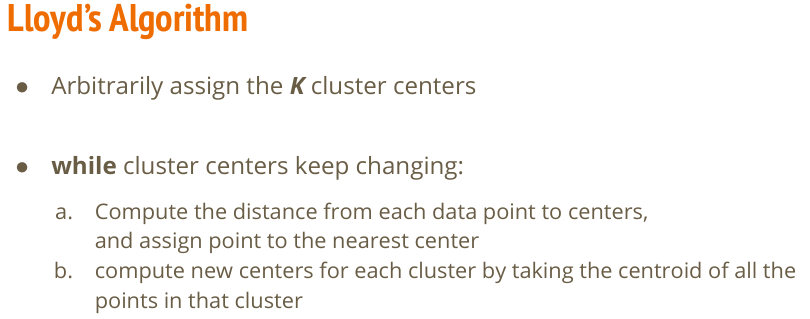

Алгоритм минимизирует функцию ошибки (**loss function**) вида

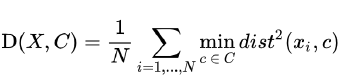

Расстояние между точками евклидово

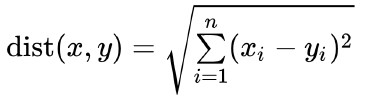

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

#### Загрузка данных

In [2]:
# Загрузим картинку
img = plt.imread("flower.png")[:,:,:3]

# Теперь в переменной img находится трехмерный массив чисел.
print(img.shape)

(427, 640, 3)


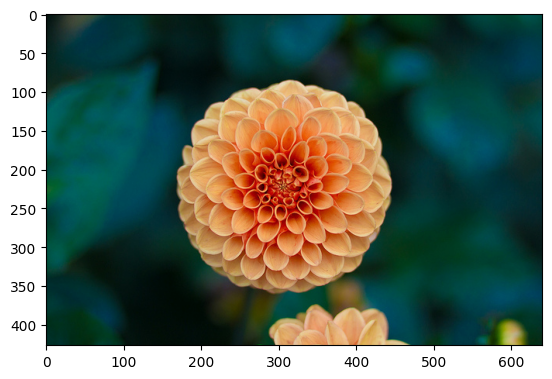

In [3]:
plt.imshow(img)
plt.show()

In [4]:
# Цвет каждой точки задается трехмерным вектором в пространстве RGB. Это наши признаки.
print(img[400, 500])

[0.04313726 0.12156863 0.11372549]


In [5]:
# Преобразуем массив в двумерный. Теперь первая координата – номер точки, вторая – ее признаки
X = img.reshape((-1,3))
print(X.shape)

(273280, 3)


#### Кластеризация

Примерная структура класса. Можно менять, если хотите

In [6]:
from scipy.spatial import distance


class KMeans:
    def __init__(
        self,
        n_clusters: int,
        max_iter: int,
        seed: int = 0,
        tol: float = 0.001,
    ) -> None:
        self.n_clusters: int = n_clusters
        self.max_iter: int = max_iter
        self.seed: int = seed
        self.tol: float = tol
        self.centroids: np.ndarray = np.empty((0, 0), dtype=np.float64)
        self.losses: list[float] = []

    def distances(self, points: np.ndarray) -> np.ndarray:
        return distance.cdist(points, self.centroids)

    @staticmethod
    def loss(dist: np.ndarray) -> float:
        return float(np.sum(np.min(dist, axis=1) ** 2))

    def initialize(self, points: np.ndarray) -> None:
        idx = np.random.choice(points.shape[0], self.n_clusters, replace=False)
        self.centroids = points[idx].astype(np.float64).copy()

    def fit_predict(self, points: np.ndarray) -> np.ndarray:
        np.random.seed(self.seed)
        self.initialize(points)
        self.losses = []

        labels = np.zeros(points.shape[0], dtype=np.intp)

        for _ in range(self.max_iter):
            dist = self.distances(points)
            labels = np.argmin(dist, axis=1)
            self.losses.append(self.loss(dist))

            new_centroids = np.array([
                points[labels == k].mean(axis=0) if np.any(labels == k) else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            if np.allclose(new_centroids, self.centroids, atol=self.tol):
                break

            self.centroids = new_centroids

        return labels


Запустим кластеризацию на наших данных

In [7]:
cls = KMeans(n_clusters=8, max_iter=100, seed=0)
y_pred = cls.fit_predict(X)
losses = cls.losses
centroids = cls.centroids

Посмотрим, как убывала функция ошибки

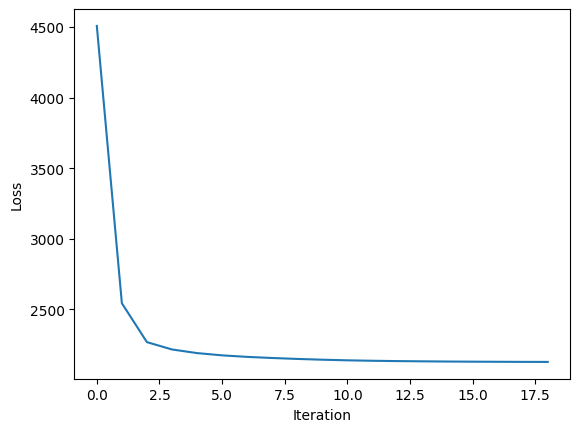

In [8]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

Наши центроиды – цвета в пространстве RGB. Можно их нарисовать

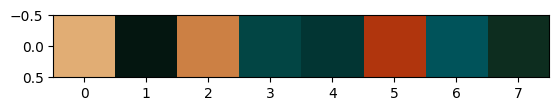

In [9]:
plt.imshow([centroids])
plt.show()

Теперь сделайте из `X` матрицу `Y`, в которой координаты каждой точки заменены на координаты центроида

In [10]:
Y = centroids[y_pred, :]

Посмотрим, что получилось

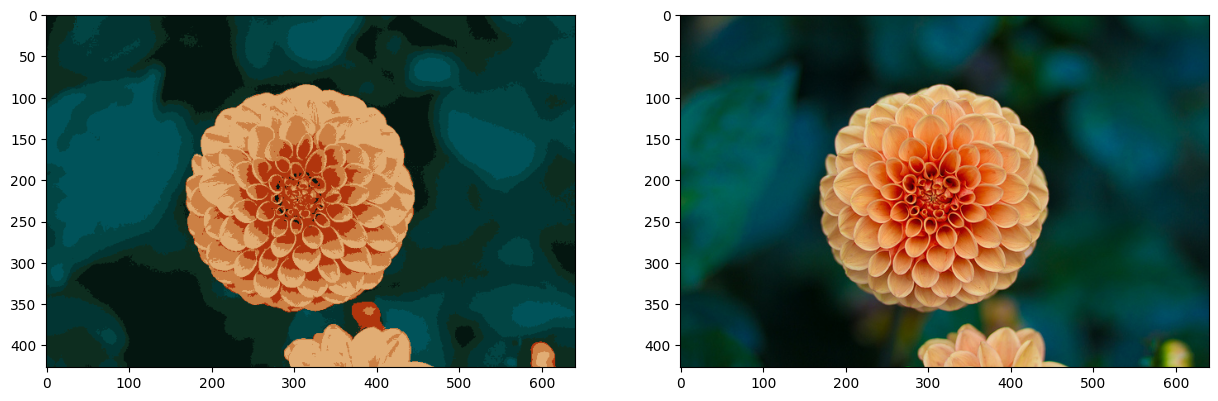

In [11]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 15))
ax1.imshow(np.array(Y).reshape(img.shape))
ax2.imshow(img)
plt.show()

Поэкспериментируйте с разным числом кластеров

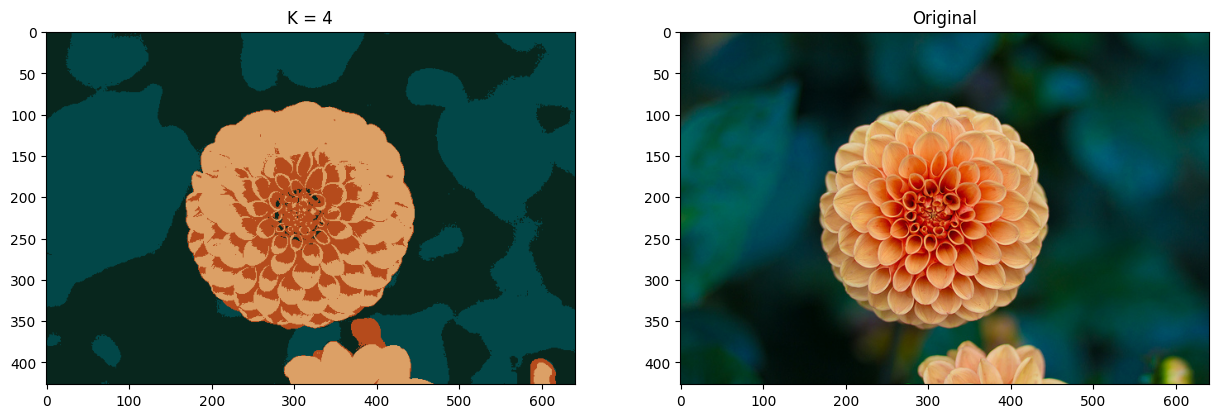

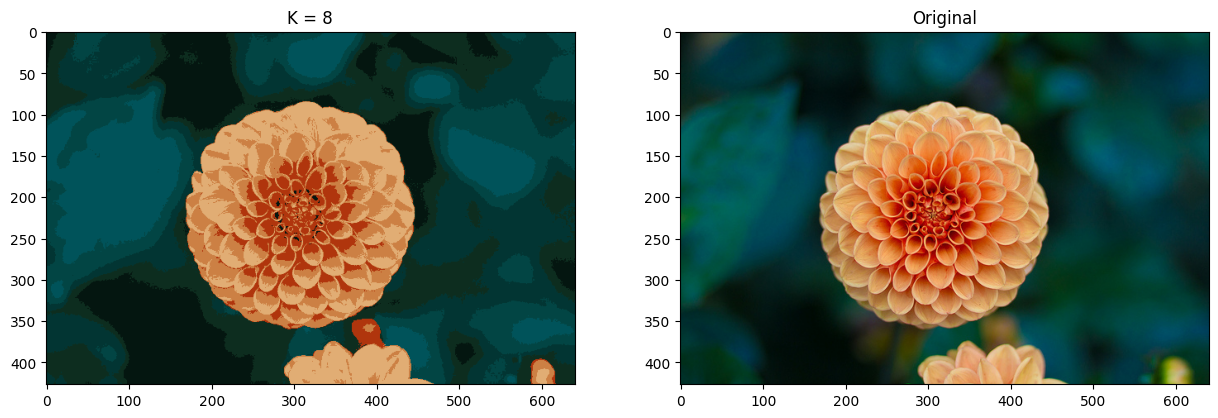

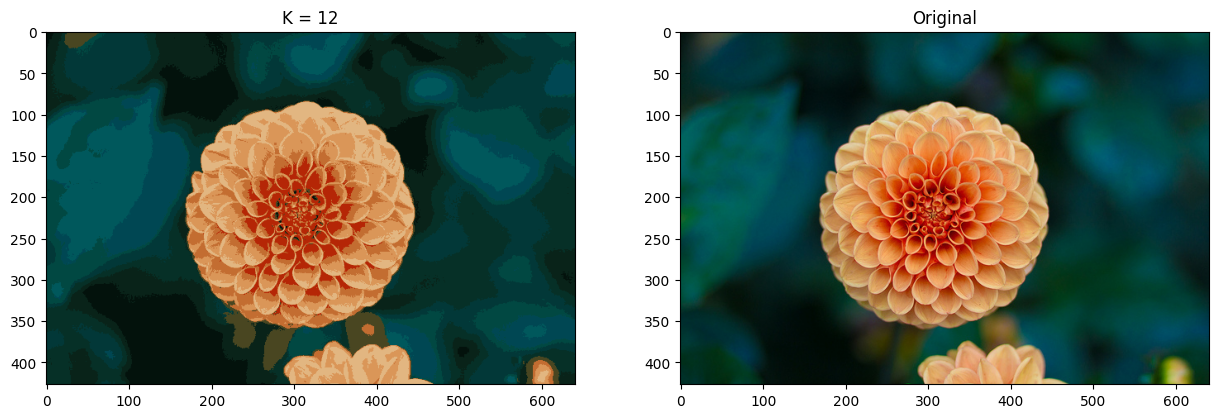

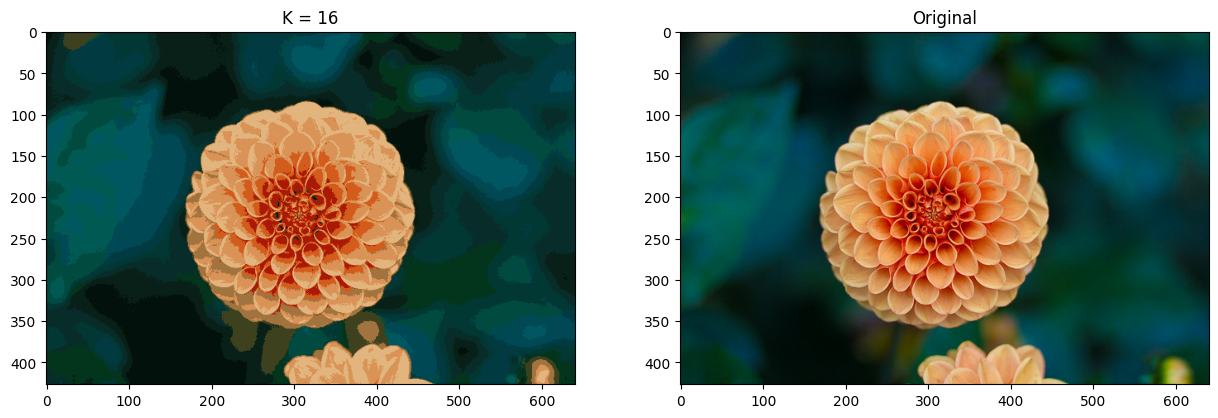

In [12]:
for k in [4, 8, 12, 16]:
    cls = KMeans(n_clusters=k, max_iter=100, seed=0)
    y_pred = cls.fit_predict(X)
    centroids = cls.centroids

    Y = centroids[y_pred, :]

    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    ax1.imshow(np.array(Y).reshape(img.shape))
    ax1.set_title(f'K = {k}')
    ax2.imshow(img)
    ax2.set_title('Original')
    plt.show()

### 2. Иерархическая кластеризация (1 балл)

Реализуйте алгоритм иерархической кластеризации

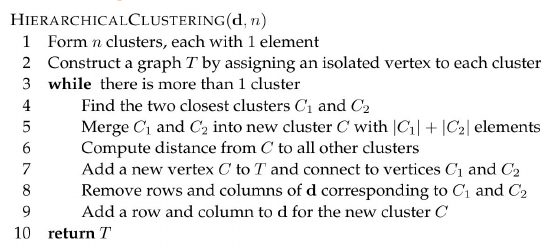

Для вычисления расстояний между кластерами используйте среднее расстояние между входящими в них точками:

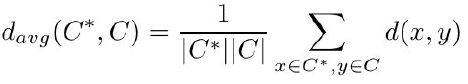



#### 2.1. Реализуйте функцию `distance_matrix`, вычисляющую матрицу попарных расстояний между точками. 
В качестве метрики мы будем использовать евклидово расстояние,

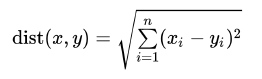


In [13]:
def distance_matrix(points: np.ndarray) -> np.ndarray:
    return distance.cdist(points, points)

#### 2.2. Реализуйте функцию `linkage`. 

На вход подается матрица расстояний. На выходе – результат кластеризации в виде матрицы связей. Строки этой матрицы соответствуют операции объединения кластеров. Каждая строка имеет вид

```[C1, C2, dist(C1, C2), N]```

где `C1` и `C2` – номера объединяемых кластеров, `dist(C1, C2)` – расстояние между объединяемыми кластерами, `N` – число точек в новом кластере

Например, кластеризации

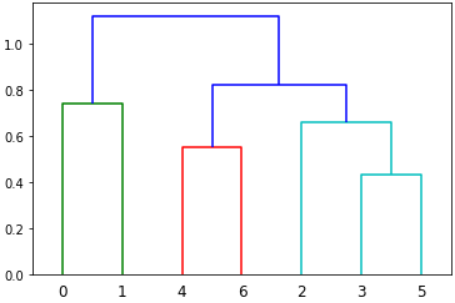

соответствует 
```
Z = [[ 3.    5.    0.43  2.  ]
     [ 4.    6.    0.55  2.  ]
     [ 2.    7.    0.66  3.  ]
     [ 0.    1.    0.74  2.  ]
     [ 8.    9.    0.82  5.  ]
     [10.   11.    1.12  7.  ]]
```


In [14]:
def linkage(d: np.ndarray) -> list[list[float]]:
    """
    Average-linkage (UPGMA) hierarchical clustering.
    """

    n: int = d.shape[0]
    # храним матрицу расстояний; неактивные кластеры маскируем np.inf
    dist = d.astype(np.float64).copy()
    np.fill_diagonal(dist, np.inf)

    sizes = np.ones(2 * n - 1, dtype=np.intp)
    ids = list(range(n))
    z: list[list[float]] = []

    for step in range(n - 1):
        i, j = (int(v) for v in np.unravel_index(np.argmin(dist), dist.shape))
        if i > j:
            i, j = j, i

        ci, cj = ids[i], ids[j]
        new_id: int = n + step
        sizes[new_id] = sizes[ci] + sizes[cj]
        a, b = sorted((ci, cj))
        z.append([float(a), float(b), float(dist[i, j]), float(sizes[new_id])])

        # Lance–Williams для UPGMA: d(new, k) = (n_i * d(i,k) + n_j * d(j,k)) / (n_i + n_j)
        new_row: np.ndarray = (sizes[ci] * dist[i] + sizes[cj] * dist[j]) / (sizes[ci] + sizes[cj])
        new_row[i] = np.inf

        dist[i] = new_row
        dist[:, i] = new_row
        dist[i, i] = np.inf
        ids[i] = new_id

        # "удаляем" строку/столбец j, маскируя их
        dist[j, :] = np.inf
        dist[:, j] = np.inf

    return z


####  Проверка 1

In [15]:
# Нам дана матрица расстояний
D = np.array([[0.  , 0.74, 0.85, 0.54, 0.83, 0.92, 0.89],
              [0.74, 0.  , 1.59, 1.35, 1.2 , 1.48, 1.55],
              [0.85, 1.59, 0.  , 0.63, 1.13, 0.69, 0.73],
              [0.54, 1.35, 0.63, 0.  , 0.66, 0.43, 0.88],
              [0.83, 1.2 , 1.13, 0.66, 0.  , 0.72, 0.55],
              [0.92, 1.48, 0.69, 0.43, 0.72, 0.  , 0.8 ],
              [0.89, 1.55, 0.73, 0.88, 0.55, 0.8 , 0.  ]])

# кластеризуем
Z = linkage(D)

# и напечатаем что получилось
print(np.array(Z))

[[ 3.    5.    0.43  2.  ]
 [ 4.    6.    0.55  2.  ]
 [ 2.    7.    0.66  3.  ]
 [ 0.    1.    0.74  2.  ]
 [ 8.    9.    0.82  5.  ]
 [10.   11.    1.12  7.  ]]


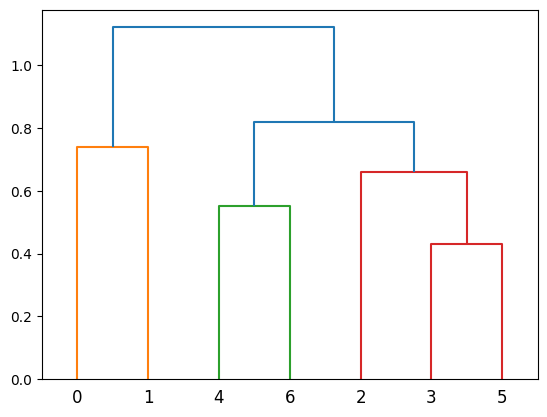

In [16]:
# для построения дендрограммы воспользуемся функцией из библиотеки scipy
from scipy.cluster.hierarchy import dendrogram

# должна получиться картинка из начала этого раздела
dendrogram(Z)
plt.show()


####  Проверка 2

In [17]:
D = np.array([
    [0.  , 0.43, 0.93, 0.85, 0.94, 0.7 , 0.95, 0.79, 0.89, 1.34, 0.8 , 0.64, 1.42, 1.37, 0.86, 1.2 , 0.49, 0.19, 1.48, 0.86],
    [0.43, 0.  , 0.66, 0.7 , 1.48, 0.58, 0.7 , 0.55, 0.68, 1.45, 1.31, 0.37, 1.24, 1.69, 0.91, 1.28, 1.04, 0.29, 0.94, 1.05],
    [0.93, 0.66, 0.  , 1.01, 1.42, 0.8 , 0.76, 1.18, 0.21, 1.18, 1.35, 0.82, 0.68, 0.85, 0.75, 1.01, 0.93, 1.03, 0.6 , 0.91],
    [0.85, 0.7 , 1.01, 0.  , 1.02, 0.22, 0.89, 0.91, 0.79, 1.47, 1.04, 1.51, 0.71, 1.63, 0.34, 1.05, 1.24, 0.56, 1.09, 1.25],
    [0.94, 1.48, 1.42, 1.02, 0.  , 1.46, 1.48, 0.95, 1.44, 1.08, 0.3 , 1.29, 1.28, 0.65, 1.  , 0.8 , 0.8 , 0.92, 1.48, 0.65],
    [0.7 , 0.58, 0.8 , 0.22, 1.46, 0.  , 0.77, 1.  , 0.65, 1.25, 1.27, 1.36, 0.81, 1.56, 0.37, 0.98, 1.17, 0.68, 0.88, 1.23],
    [0.95, 0.7 , 0.76, 0.89, 1.48, 0.77, 0.  , 1.41, 1.08, 1.61, 1.65, 0.89, 0.76, 1.32, 0.64, 0.7 , 0.59, 1.07, 0.49, 0.91],
    [0.79, 0.55, 1.18, 0.91, 0.95, 1.  , 1.41, 0.  , 1.05, 0.73, 1.08, 0.7 , 1.49, 1.17, 1.  , 1.34, 1.45, 0.49, 1.06, 1.3 ],
    [0.89, 0.68, 0.21, 0.79, 1.44, 0.65, 1.08, 1.05, 0.  , 0.96, 1.09, 0.94, 0.44, 1.06, 0.9 , 1.47, 1.2 , 0.79, 1.04, 1.39],
    [1.34, 1.45, 1.18, 1.47, 1.08, 1.25, 1.61, 0.73, 0.96, 0.  , 0.96, 1.1 , 1.05, 0.48, 1.36, 1.26, 1.38, 1.38, 1.03, 1.38],
    [0.8 , 1.31, 1.35, 1.04, 0.3 , 1.27, 1.65, 1.08, 1.09, 0.96, 0.  , 1.08, 1.09, 0.79, 1.4 , 1.03, 1.02, 0.78, 1.79, 0.86],
    [0.64, 0.37, 0.82, 1.51, 1.29, 1.36, 0.89, 0.7 , 0.94, 1.1 , 1.08, 0.  , 1.42, 1.2 , 1.61, 1.3 , 0.86, 0.68, 1.04, 0.83],
    [1.42, 1.24, 0.68, 0.71, 1.28, 0.81, 0.76, 1.49, 0.44, 1.05, 1.09, 1.42, 0.  , 0.99, 0.84, 1.2 , 1.21, 1.22, 0.97, 1.58],
    [1.37, 1.69, 0.85, 1.63, 0.65, 1.56, 1.32, 1.17, 1.06, 0.48, 0.79, 1.2 , 0.99, 0.  , 1.13, 0.61, 1.  , 1.6 , 0.81, 0.83],
    [0.86, 0.91, 0.75, 0.34, 1.  , 0.37, 0.64, 1.  , 0.9 , 1.36, 1.4 , 1.61, 0.84, 1.13, 0.  , 0.68, 0.89, 0.86, 0.65, 1.04],
    [1.2 , 1.28, 1.01, 1.05, 0.8 , 0.98, 0.7 , 1.34, 1.47, 1.26, 1.03, 1.3 , 1.2 , 0.61, 0.68, 0.  , 0.92, 1.47, 0.47, 0.42],
    [0.49, 1.04, 0.93, 1.24, 0.8 , 1.17, 0.59, 1.45, 1.2 , 1.38, 1.02, 0.86, 1.21, 1.  , 0.89, 0.92, 0.  , 0.9 , 1.18, 0.49],
    [0.19, 0.29, 1.03, 0.56, 0.92, 0.68, 1.07, 0.49, 0.79, 1.38, 0.78, 0.68, 1.22, 1.6 , 0.86, 1.47, 0.9 , 0.  , 1.56, 1.21],
    [1.48, 0.94, 0.6 , 1.09, 1.48, 0.88, 0.49, 1.06, 1.04, 1.03, 1.79, 1.04, 0.97, 0.81, 0.65, 0.47, 1.18, 1.56, 0.  , 0.84],
    [0.86, 1.05, 0.91, 1.25, 0.65, 1.23, 0.91, 1.3 , 1.39, 1.38, 0.86, 0.83, 1.58, 0.83, 1.04, 0.42, 0.49, 1.21, 0.84, 0.  ]
])

Выведите Linkage матрицу и постройте дендрограмму

[[ 0.         17.          0.19        2.        ]
 [ 2.          8.          0.21        2.        ]
 [ 3.          5.          0.22        2.        ]
 [ 4.         10.          0.3         2.        ]
 [14.         22.          0.355       3.        ]
 [ 1.         20.          0.36        3.        ]
 [15.         19.          0.42        2.        ]
 [ 9.         13.          0.48        2.        ]
 [ 6.         18.          0.49        2.        ]
 [12.         21.          0.56        3.        ]
 [11.         25.          0.56333333  4.        ]
 [ 7.         30.          0.6325      5.        ]
 [16.         26.          0.705       3.        ]
 [28.         32.          0.78166667  5.        ]
 [24.         29.          0.80666667  6.        ]
 [23.         27.          0.87        4.        ]
 [31.         34.          0.995      11.        ]
 [33.         36.          1.05890909 16.        ]
 [35.         37.          1.184375   20.        ]]


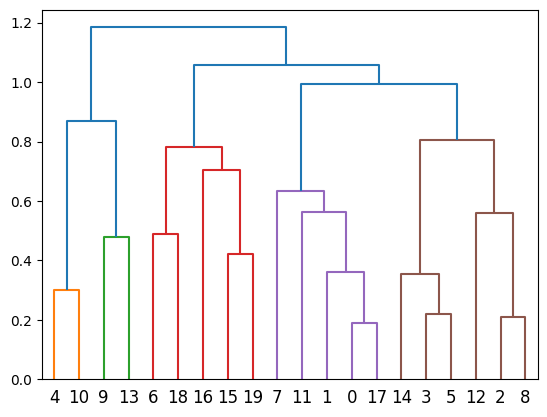

In [18]:
Z2 = linkage(D)
print(np.array(Z2))
dendrogram(Z2)
plt.show()

#### 2.3. Digits dataset

In [19]:
from sklearn import datasets

# загрузим датасет Digits. Он состоит из рукописных изображений цифр
digits = datasets.load_digits().images

In [20]:
# выберем 20 случайных изображений
digits = np.random.permutation(digits)[:20]

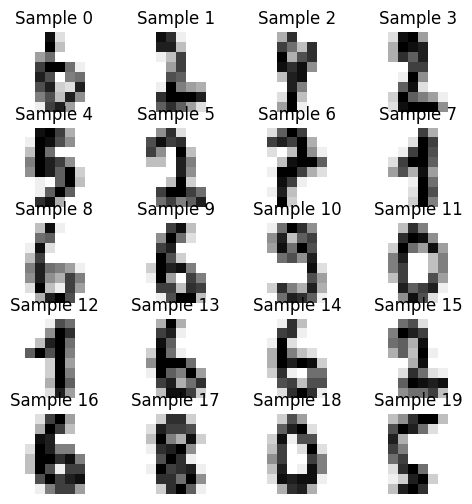

In [21]:
# вот они
_, axes = plt.subplots(nrows=5, ncols=4, figsize=(6, 6))
for i, (ax, image) in enumerate(zip(axes.flatten(), digits)):
    ax.set_axis_off()
    ax.imshow(image, cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Sample {i}')

In [22]:
# каждое изображение – матрица размера (8, 8). Давайте вытянем ее в вектор признаков
XX = digits.reshape((digits.shape[0], -1))

**Кластеризуйте вектора и постройте дендрограмму. Какие выводы можно из нее сделать?**

[[ 7.         12.         18.86796226  2.        ]
 [13.         14.         20.19900988  2.        ]
 [ 9.         16.         21.11871208  2.        ]
 [11.         18.         23.2594067   2.        ]
 [ 5.         15.         23.72762104  2.        ]
 [ 8.         21.         24.30265508  3.        ]
 [22.         25.         30.24403727  5.        ]
 [ 1.         24.         30.83956277  3.        ]
 [ 0.         26.         37.37117013  6.        ]
 [ 3.         27.         37.49412877  4.        ]
 [17.         28.         38.53974318  7.        ]
 [10.         23.         38.88139121  3.        ]
 [ 4.         30.         44.66046391  8.        ]
 [31.         32.         45.07692201 11.        ]
 [ 2.         29.         45.50525285  5.        ]
 [33.         34.         48.99860169 16.        ]
 [20.         35.         53.13832133 18.        ]
 [ 6.         36.         53.72369984 19.        ]
 [19.         37.         54.32783542 20.        ]]


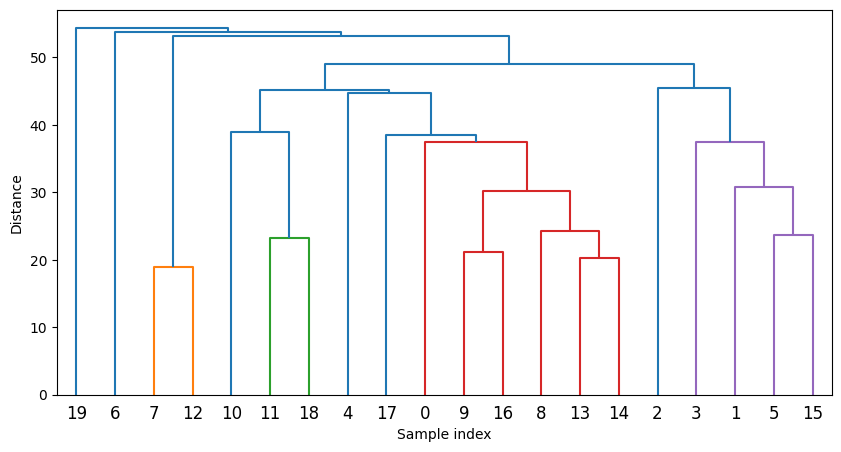

In [23]:
DD = distance_matrix(XX)
Zd = linkage(DD)
print(np.array(Zd))
plt.figure(figsize=(10, 5))
dendrogram(Zd, labels=[str(i) for i in range(XX.shape[0])])

plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

**Выводы:**

Дендрограмма показывает, что изображения одной и той же цифры в большинстве случаев оказываются ближе друг к другу в пространстве признаков (вытянутых пикселей 8×8) и объединяются в кластеры на низких уровнях иерархии. Однако визуально похожие цифры (например, 1 и 7, 3 и 8, 4 и 9) могут смешиваться, поскольку евклидово расстояние по сырым пикселям не учитывает форму. Чем выше уровень объединения на дендрограмме, тем сильнее различаются объекты в этих кластерах.
